# PedSilicoICH: Part 1. Phantoms

This notebook introduces the features and uses of the PedSilicoICH tool for generating anthropomorphic ground truth phantoms - currently based on the MIDA phantom and NIHPD MR brain atlases as a base - with models of intracranial hemorrhage, specifically intraparenchymal (IPH), epiural (EDH), and subural (SDH) hemorrages.liver metastases.

This notebook also introduces concepts of the `Phantoms` Class

## Select a starting phantom

In [1]:
import insilicoICH
insilicoICH.available_phantoms

Loaded 5 plugins via entry points.
Discovered Phantom Types (Classes):
- 0.0 yr UNC Head - functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom'))
- 1.0 yr UNC Head - functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom'))
- 2.0 yr UNC Head - functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom'))
- 6.5 yr NIHPD Head - functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom'))
- 9.0 yr NIHPD Head - functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/gpfs_

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/gpfs_projects/brandon.nelson/pedsilicoICH/phantoms/NIHPD_Head_Phantom'))

In [2]:
phantom = insilicoICH.load_phantom(38)
phantom


        Phantom Class: MIDA_Head
        Age (years): 38
        Shape (voxels): [480, 480, 350]
        Size (mm): [239.95967388 240.         175.        ]
        
        Number of lesions: 0
        Lesion locations [voxel index (z, x, y)]: []
        Mass effect: False
        

In [3]:
phantom.resize(3*[240], mode='nearest')

In [4]:
phantom.get_skull_map().shape

(240, 240, 175)

In [5]:
phantom.insert_lesion('IPH', mass_effect=True, seed=42, intensity=80, volume=10, edema=1)


        Phantom Class: MIDA_Head
        Age (years): 38
        Shape (voxels): [240, 240, 175]
        Size (mm): [239.95967388 240.         175.        ]
        
        Number of lesions: 1
        Lesion locations [voxel index (z, x, y)]: [(np.int64(65), np.int64(97), np.int64(63))]
        Mass effect: True
        

In [6]:
phantom.get_CT_number_phantom().shape

(240, 240, 175)

In [7]:
import matplotlib.pyplot as plt
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

## define a set of lesions to insert
This can be done individual or arranged into a list if inserting multiple as demonstrated here.

In [8]:
import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(70, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)
lesions

[{'volume': np.float64(0.05),
  'intensity': np.float64(70.0),
  'lesion_type': 'IPH',
  'seed': 336},
 {'volume': np.float64(0.275),
  'intensity': np.float64(60.0),
  'lesion_type': 'IPH',
  'seed': 336},
 {'volume': np.float64(0.5),
  'intensity': np.float64(50.0),
  'lesion_type': 'IPH',
  'seed': 336}]

## Insert the lesions into the selected phantom

In [9]:
for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

inserting lesion 0/3:
{'volume': np.float64(0.05), 'intensity': np.float64(70.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 1/3:
{'volume': np.float64(0.275), 'intensity': np.float64(60.0), 'lesion_type': 'IPH', 'seed': 336}

inserting lesion 2/3:
{'volume': np.float64(0.5), 'intensity': np.float64(50.0), 'lesion_type': 'IPH', 'seed': 336}




        Phantom Class: MIDA_Head
        Age (years): 38
        Shape (voxels): [240, 240, 175]
        Size (mm): [239.95967388 240.         175.        ]
        
        Number of lesions: 4
        Lesion locations [voxel index (z, x, y)]: [(np.int64(65), np.int64(97), np.int64(63)), (np.int64(77), np.int64(59), np.int64(125)), (np.int64(76), np.int64(86), np.int64(78)), (np.int64(76), np.int64(60), np.int64(105))]
        Mass effect: False
        

Checkout the results

In [10]:
%pip install -q matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


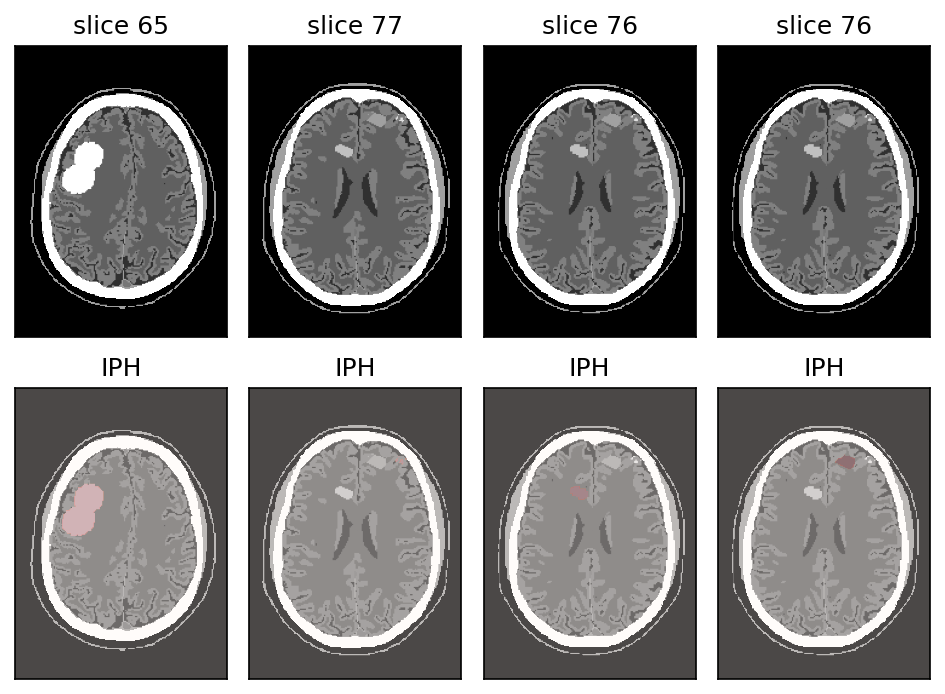

In [ ]:
from utils import scrollview, show_lesions
show_lesions(phantom, 'brain')

In [12]:
scrollview(phantom.get_CT_number_phantom())

interactive(children=(IntSlider(value=120, description='idx', max=239), Output()), _dom_classes=('widget-inter…

In [ ]:
phantom.get_sutures?

Object `phantom.get_sutures` not found.


In [ ]:
import matplotlib.pyplot as plt
if hasattr(phantom, 'get_sutures'):
    sutures = phantom.get_sutures()
    f, axs = plt.subplots(1, 3)
    for dim, ax in enumerate(axs.flatten()):
        ax.imshow(sutures.max(axis=dim))

Some simple analytical geometric lesions are included in the module `lesion_insertion`, see the help string for more details

In [ ]:
phantom.insert_lesion?

Signature:
phantom.insert_lesion(
    lesion_type,
    volume=5,
    intensity=50,
    mass_effect=False,
    seed=None,
    **kwargs,
)
Docstring:
Inserts a lesion of a specified type into the phantom array.

:param lesion_type: str, type of the lesion. Options include 'IPH' (intraparenchymal), 'EDH' (epidural), and 'SDH' (subdural).
:param volume: float, volume of the lesion in mL. Default is 5.
:param intensity: int, CT number of the lesion in HU. Default is 50.
:param mass_effect: bool, whether to apply mass effect processing to displace brain tissue following lesion insertion. Default is False.
:param seed: int, optional seed for reproducible lesion insertion. Default is None.
:param kwargs: additional keyword arguments to pass to the lesion insertion function.
:return: self, the updated LesionPhantom object.
File:      ~/Dev/PedSilicoICH/src/insilicoICH/phantoms/base_phantoms.py
Type:      method

[]

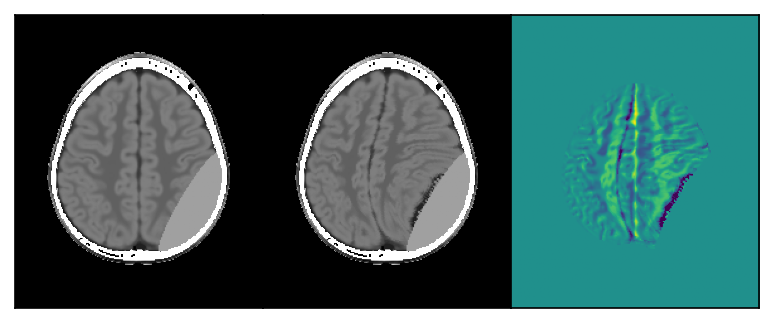

In [ ]:
from insilicoICH import load_phantom
from utils import ctshow

seed = 42
age = 6.5
display = 'brain'

phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=40, mass_effect=False, seed=seed)

phantom_me = load_phantom(age)
phantom_me.insert_lesion('EDH', volume=40, mass_effect=True, seed=seed)
phantom_no_me_image = phantom._phantom[phantom._lesion_coords[0][0]]
phantom_me_image = phantom_me._phantom[phantom_me._lesion_coords[0][0]]

f, axs = plt.subplots(1, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))
ctshow(phantom._phantom[phantom._lesion_coords[0][0]], display, fig=f, ax=axs[0])
ctshow(phantom_me._phantom[phantom_me._lesion_coords[0][0]], display, fig=f, ax=axs[1])
axs[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
axs[2].set_xticks([])
axs[2].set_yticks([])

Each lesion type has its own specific method, `add_<lesion_type>`, checkout the help string of each for more details

### Intraparenchymal (round)

In [ ]:
phantom.add_round_lesion?

Signature:
phantom.add_round_lesion(
    volume: int = 10,
    intensity: int = 50,
    material: str = 'white matter',
    eccentricity: float = 0.5,
    mass_effect: bool | float = 0.5,
    edema: bool | int = False,
    complexity: int = 3,
    overlap: float = 0.4,
    seed: int | None = None,
) -> tuple
Docstring:
adds round lesion to img in random location within mask of size radius
and intensity level intensity

See parameter descriptions below for further modifications that can
be added:

:param volume: int or list of ints, volume of the sphere lesion in mL,
    if provided a list it will make concentric lesions
:param intensity: int or list of ints, intensity of the sphere lesion
    in HU, if provided a list it will make concentric lesions of
    intensities
:param material: which material region to insert lesion into,
    self.materials for options
:param eccentricity: between 0, 1 defines how elongated the lesions
    are, with 0 being spherical, 1 being very oblong
:param 

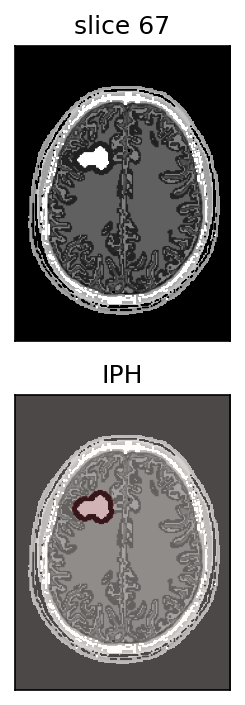

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(38, shape=phantom.shape)
phantom.insert_lesion('IPH', volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.1, mass_effect=True) 
show_lesions(phantom)

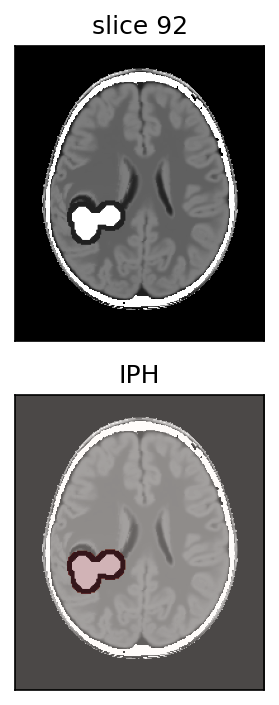

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(age)
phantom.insert_lesion('IPH', volume=volume, intensity=intensity, complexity=3, edema=7, eccentricity=0.1, mass_effect=True) 
show_lesions(phantom)

### Subdural (SDH)

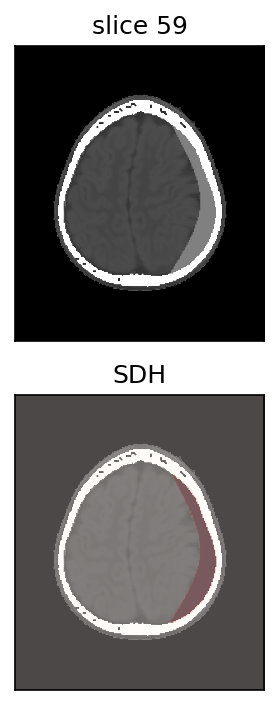

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('SDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'subdural')

### Epidural (EDH)

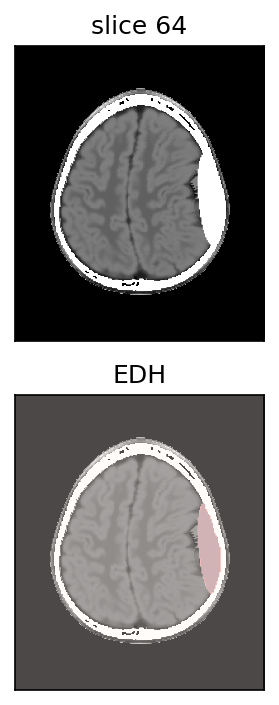

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume, intensity=intensity, mass_effect=True) 
show_lesions(phantom, 'brain')

### Multiple (TODO: ensure no overlapping of hemorrhages)

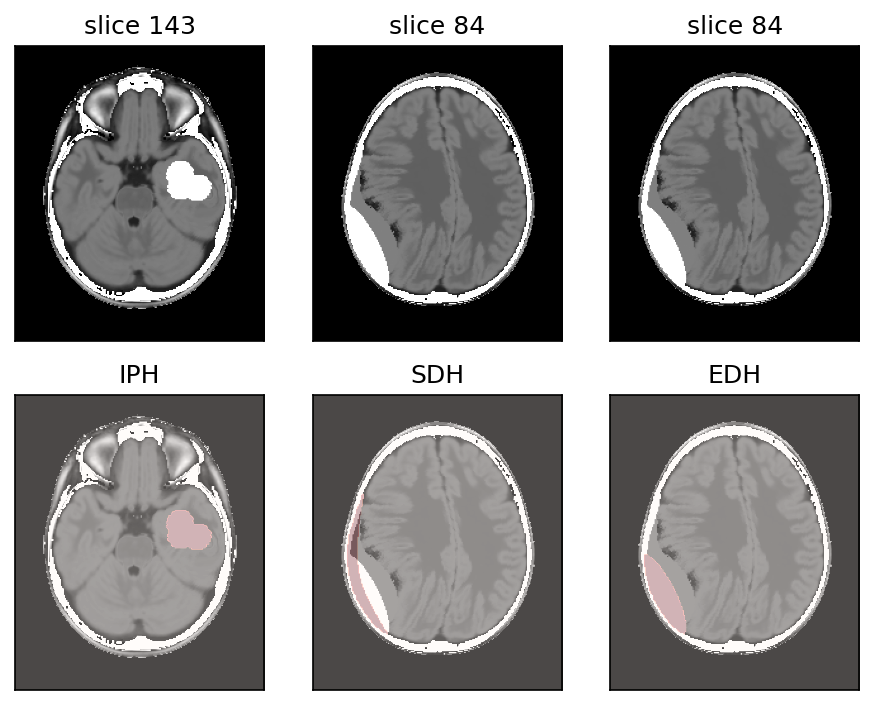

In [ ]:
seed = 32
mass_effect = True
phantom = load_phantom(age)
intensity = 100
phantom.insert_lesion('IPH', volume=3, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('SDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('EDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 

show_lesions(phantom,'brain')

In [ ]:
phantom


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): [189, 233, 197]
        Size (mm): [151.20000225 186.40000278 157.60000235]
        
        Number of lesions: 3
        Lesion locations [voxel index (z, x, y)]: [(np.int64(143), np.int64(102), np.int64(140)), (84, 137, 35), (84, 157, 41)]
        Mass effect: True
        

In [ ]:
lesions = phantom.get_lesion_mask()
lesions.shape

(189, 233, 197)

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [ ]:
phantom._lesion_coords

[(np.int64(143), np.int64(102), np.int64(140)), (84, 137, 35), (84, 157, 41)]

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [ ]:
from monai.transforms import RandAffine

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=1, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

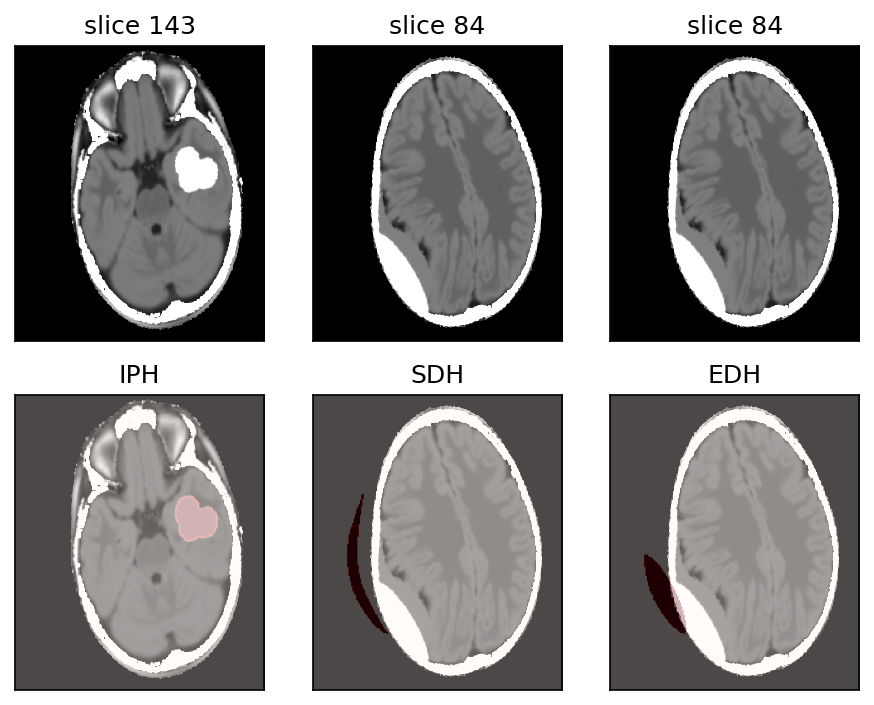

In [ ]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.